In [22]:
%%html
<style>
.rendered_html p {
    font-size: 17px;
    font-family: "Times New Roman";
    text-align:justify}
</style>

# Support Vector Machine Python Example

by Cory Maklin<br>
Aug 12, 2019 

Support Vector Machine (SVM) is a supervised machine learning algorithm capable of performing classification, regression and even outlier detection. The linear SVM classifier works by drawing a straight line between two classes. All the data points that fall on one side of the line will be labeled as one class and all the points that fall on the other side will be labeled as the second. Sounds simple enough, but there’s an infinite amount of lines to choose from. How do we know which line will do the best job of classifying the data? This is where the LSVM algorithm comes in to play. The LSVM algorithm will select a line that not only separates the two classes but stays as far away from the closest samples as possible. In fact, the “support vector” in “support vector machine” refers to two position vectors drawn from the origin to the points which dictate the decision boundary.

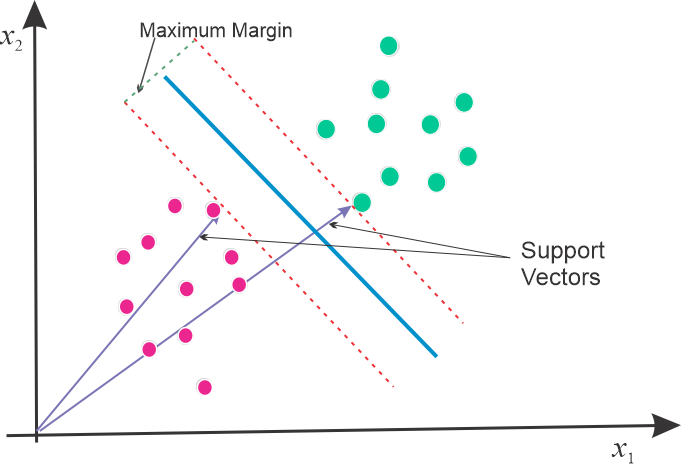

## Algorithm
Suppose, we had a vector w which is always normal to the hyperplane (perpendicular to the line in 2 dimensions). We can determine how far away a sample is from our decision boundary by projecting the position vector of the sample onto the vector $w$. As a quick refresher, the dot product of two vectors is proportional to the projection of the first vector onto the second.

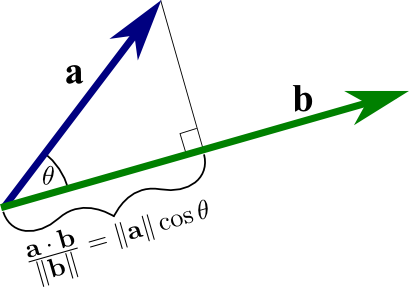

If it’s a positive sample, we’re going to insist that the proceeding decision function (the dot product of w and the position vector of a given sample plus some constant) returns a value greater than or equal to $1$.
$$\overrightarrow{w}\cdot\overrightarrow{x}_+ + b \ge 1$$
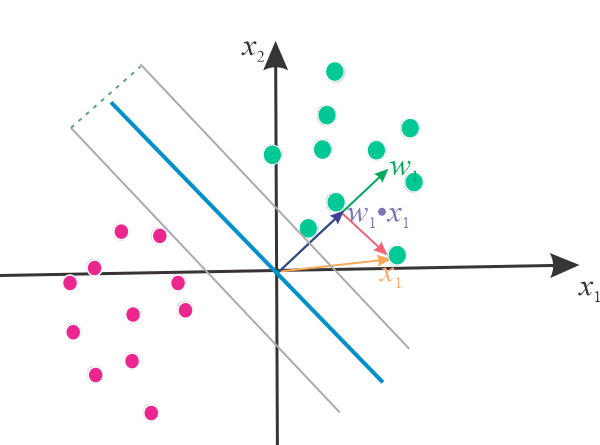


Similarly, if it’s a negative sample, we’re going to insist that the proceeding decision function returns a value smaller than or equal to $-1$.

$$ \overrightarrow{w}\cdot \overrightarrow{x}_-+b \le -1 $$

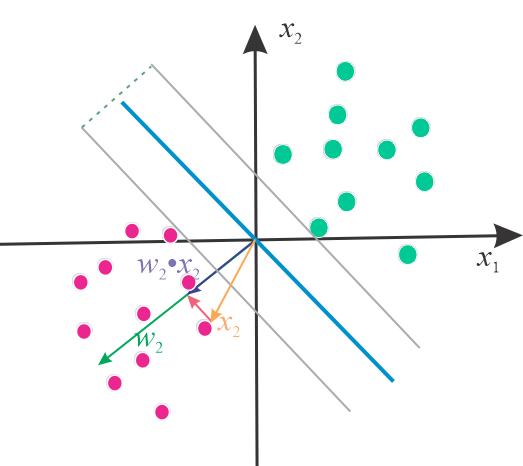

In other words, we won’t consider any samples located between the decision boundary and support vectors.
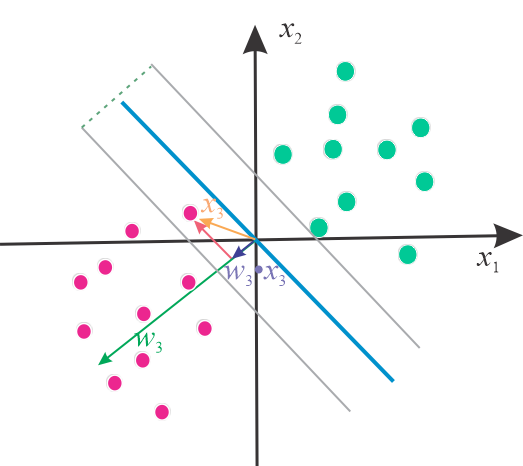


We introduce an additional variable stickily for convenience. The variable $y$ will be equal to __positive one__ for all positive samples and __negative one__ for all negative samples.

$$
  y =\begin{cases}
    +1, & \text{for $+$ samples}.\\
    -1, & \text{for $-$ samples}.
  \end{cases}
$$

After multiplying by $y$, the equations for the positive and negative samples are equal to one another.
$$y_i \left( \overrightarrow{w}\cdot\overrightarrow{x}_+ + b\right) \ge 1$$
$$y_i \left( \overrightarrow{w}\cdot\overrightarrow{x}_- + b\right) \ge 1$$

Meaning, we can simplify the constraints down to a single equation.
$$y_i \left( \overrightarrow{w}\cdot \overrightarrow {x}_i + b\right) - 1 = 0$$

Next, we need to address the process by which we go about maximizing the margin. To get an equation for the width of the margin, we subtract the first support vector from the one below it and multiply the result by the unit vector of w, which is always perpendicular to the decision boundary.

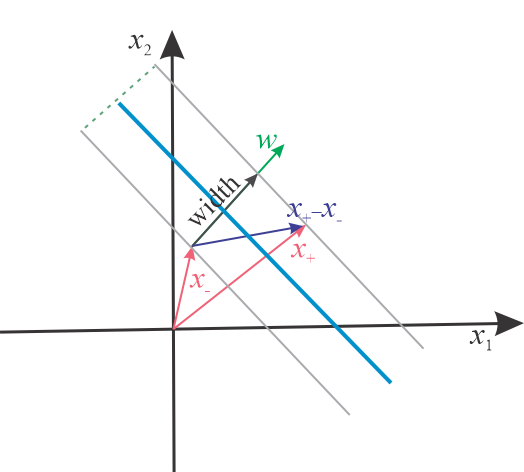

$$ \text{width} = (\overrightarrow{x}_+ - \overrightarrow{x}_-) \cdot \frac{\overrightarrow{w}}{\left\lVert w \right\rVert }$$
Using the constraints from above and a bit of algebra, we get the following.

\begin{aligned}
&y_{i} \left(\overrightarrow{w} \cdot \overrightarrow{x}_{i}  + b \right)- 1 = 0 \\
&(1)(\overrightarrow{w} \cdot \overrightarrow{x}_{+}) + b-1 = 0\text{, when }y_{i} =1 \\
\end{aligned}

\begin{equation}
\begin{aligned}
&\overrightarrow{w} \cdot \overrightarrow{x}_{+} = 1 - b  \\
&(-1)\left(\overrightarrow{w} \cdot \overrightarrow{x}_{-} + b\right)-1 = 0 \text{, when } y_{i} = -1\\
&\overrightarrow{w} \cdot \overrightarrow{x}_{-} = -1 - b \\
\end{aligned}
\end{equation}


\begin{equation}
\begin{aligned}
&\text{width} =\left(\left(\overrightarrow{w} \cdot \overrightarrow{x}_+ \right)-\left(\overrightarrow{w} \cdot \overrightarrow{x}_- \right)\right) \frac{1}{\left\lVert w \right\rVert} \\
&\text{width} =\left((1-b)-(-1-b) \right) \frac{1}{\left\lVert w \right\rVert} \\
\end{aligned}
\end{equation}

\begin{equation}
\begin{aligned}
&\text{width} =\frac{2}{\left\lVert w \right\rVert} \\
\end{aligned}
\end{equation}

Therefore, in order to select the optimal decision boundary, we must maximize the equation we just computed. We apply a few more tricks before proceeding.
$$
\text{max} \quad \text{width} = {\frac{2}{\left\lVert w \right\rVert}}
$$
which is proportional to:
$$
\text{max} \quad \frac{1}{\left\lVert w \right\rVert}
$$
which is equivalent to:
$$ \text{min} \quad \left\lVert w \right\rVert $$
We are going to cheat a little and use: <br>
$$ \text{min} \quad \frac{1}{2}\left\lVert w \right\rVert^2 \quad \text{since} \frac{d}{dx}\frac{1}{2}x^2 = x$$

Now, in most machine learning algorithms, we’d use something like gradient descent to minimize said function, however, for support vector machines, we use the Lagrangian. The Lagrangian is beyond the scope of this article but if you’re in need of a quick crash course, I recommend checking out Khan Academy. In essence, using Lagrangian, we can solve for the global minimum like we’d do in high school level calculus (i.e. take the derivative of the function and make it equal to zero). The Lagrange tells us to subtract the cost function by the summation over all the constraints where each of those constraints will be multiplied by some constant alpha (normally written as lambda for the Lagrangian).

\begin{aligned}
L =& \frac{1}{2}\left\lVert \overrightarrow{w} \right\rVert ^2- \sum^n_i\alpha_i[y_i(\overrightarrow{w} \cdot \overrightarrow{x} + b) - 1] \\
&\frac{\partial L}{\partial w}=\overrightarrow{w} - \sum^n_i{\alpha_iy_ix_i} = 0 \\
&\overrightarrow{w} = \sum^n_i{\alpha_iy_ix_i}  \\
&\frac{\partial L}{\partial b}= -\sum^n_i{\alpha_iy_i} = 0 \\
&\sum^n_i{\alpha_iy_i} = 0 \\
\end{aligned}




Then, we perform some more algebra, plugging the equations we found in the previous step back into the original equation.
\begin{align}
L =& \frac{1}{2}\left\lVert \overrightarrow{w} \right\rVert^2 - \sum^n_i{\alpha_i[y_i(\overrightarrow{w} \cdot \overrightarrow{x}+b)-1]}, \quad &\text{where} \; \overrightarrow{w}=&\sum^n_i{\alpha_iy_ix_i} \\
L =& \frac{1}{2}\sum^n_i{\alpha_iy_i\overrightarrow{x}_i} \cdot \sum^n_i{\alpha_jy_j\overrightarrow{x}_j} - \sum^n_i{\alpha_iy_j\overrightarrow{w} \cdot \overrightarrow{x} - \sum^n_i{\alpha_iy_ib} +\sum^n_i{\alpha_i}}, \quad &\text{where} \; \overrightarrow{w}=&\sum^n_i{\alpha_iy_ix_i}, \sum^n_i{\alpha_iy_i}=0 \\
L =& \frac{1}{2}\sum^n_i \sum^n_j{\alpha_jy_j \alpha_iy_i \overrightarrow{x}_i \cdot \overrightarrow{x}_j} - \sum^n_i \sum^n_j{\alpha_jy_j \alpha_iy_i \overrightarrow{x}_i \cdot \overrightarrow{x}_j} - 0 + \sum^n_i{\alpha_i} \\
L =& -\frac{1}{2}\sum^n_i \sum^n_j{\alpha_jy_j \alpha_iy_i \overrightarrow{x}_i \cdot \overrightarrow{x}_j}  + \sum^n_i{\alpha_i}
\end{align}

Before we can proceed any further, we need to express the equation in terms of matrices instead of summations. The reason being, the qp function from the ```CVXOPT``` library, which we’ll use to solve the Lagrangian, accepts very specific arguments. Thus, we need to go from:

$$L=\sum^n_i{\alpha_i}-\frac{1}{2}\sum^n_i\sum^n_j{\alpha_i\alpha_jy_iy_jx_ix_j}, $$
where,
$$ \alpha_i \ge 1$$
and,
$$\sum^n_i {\alpha_iy_i} = 0 $$
To
\begin{equation}
\begin{aligned}
\text{minimize} \quad  & (1/2)x^TPx + q^Tx \\
\text{subject to} \quad & Gx \preceq h \\
& Ax = b
\end{aligned}
\end{equation}

We can achieve this using the following identities:
$$\left(A^T\right)^T = A \\
a \cdot b = \sum^n_i ab\\
v^Tw = [v_1, \dots , vn] \begin{bmatrix}w_1 \\ \vdots \\ w_n \end{bmatrix} = v_1w_1 + \ddots + v_nw_n =\boldsymbol{v} \cdot \boldsymbol{w} $$
$$
\begin{equation}
\begin{aligned}
&-\alpha = \begin{bmatrix}\alpha_1 & \alpha_2 & \dots & \alpha_n \end{bmatrix}^T \\
&\boldsymbol{-y} = \begin{bmatrix}y_1 & y_2 & \dots& y_n \end{bmatrix}^T \\
&\boldsymbol{-1} = \begin{bmatrix} 1 & 1 &\dots & 1 \end{bmatrix}^T \\
&\boldsymbol{-X_{(d \times N)}} = \begin{bmatrix}x_1y_1 & x_2y_2 & \dots& x_Ny_N \end{bmatrix}^T 
\end{aligned}
\end{equation}
$$
in applying them, we get:

\begin{equation}
\begin{aligned}
L &= \sum^n_i{\alpha_i} -\frac{1}{2}\left( \sum^n_i{\alpha_iy_ix_i}\right) \cdot \sum\left( \sum^n_j{\alpha_jy_jx_j}\right)  \\
&= 1^T\alpha - \frac{1}{2}\left( \alpha^TX\right) \cdot \left( \alpha^TX\right) \text{since} X=[x_1y_1 \ldots] \\
&=   1^T\alpha - \frac{1}{2}\left( \alpha^TX\right)^T \left( \alpha^TX\right)\\
&=   1^T\alpha - \frac{1}{2} \alpha X^T\alpha^TX  \\ 
&=   1^T\alpha - \frac{1}{2} X^T\alpha^TX\alpha  
\end{aligned}
\end{equation}

__Note:__ $X = \left[ x_1y_1, x_2y_2, \ldots, x_ny_n \right]$ is the multiplication of $x$ and $y$ (not to be confused with $x$) <br>
Then, we map the variables to those expected by the [CVXOPT](https://cvxopt.org/userguide/coneprog.html#quadratic-programming) library.

### Then the SVM problem:
\begin{equation}
\begin{aligned}
\text{maximize} \quad  & 1^T\alpha - \frac{1}{2}\alpha^TX^TX\alpha \\
\text{subject to} \quad & \alpha  \succeq 0 \\
& y^T\alpha = 0
\end{aligned}
\end{equation}
Can be rewritten as,

\begin{equation}
\begin{aligned}
\text{minimize} \quad  & (1/2)x^TPx + q^Tx \\
\text{subject to} \quad & Gx \preceq h \\
& Ax = b
\end{aligned}
\end{equation}
where
$$
\begin{aligned}
X =& \alpha \\
P =& X^TX \\
q =& -1_N \\
G =& -1_{N \times N} \\
h =& 0_N \\
A =& y^T \\
v =& 0
\end{aligned}
$$

# Python Code
Now, we’re ready to write some code. We’ll start off by importing the necessary libraries.

In [1]:
!pip install cvxopt

In [3]:
import numpy as np
import cvxopt
#from sklearn.datasets.samples_generator import make_blobs
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification
from matplotlib import pyplot as plt
from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix

## Manually implementation of SVM 
Then, we define our __SVM__ class. As we mentioned previously, instead of using gradient descent to find the best fitting line as in the case of Linear Regression, we can directly solve for $w$ and $b$ using the Lagrangian.

In [4]:
class SVM:
    def fit(self, X, y):
        n_samples, n_features = X.shape
        # P = X^T X
        K = np.zeros((n_samples, n_samples))
        for i in range(n_samples):
            for j in range(n_samples):
                K[i,j] = np.dot(X[i], X[j])
        P = cvxopt.matrix(np.outer(y, y) * K)
        # q = -1 (1xN)
        q = cvxopt.matrix(np.ones(n_samples) * -1)
        # A = y^T 
        A = cvxopt.matrix(y, (1, n_samples))
        # b = 0 
        b = cvxopt.matrix(0.0)
        # -1 (NxN)
        G = cvxopt.matrix(np.diag(np.ones(n_samples) * -1))
        # 0 (1xN)
        h = cvxopt.matrix(np.zeros(n_samples))
        solution = cvxopt.solvers.qp(P, q, G, h, A, b)
        # Lagrange multipliers
        a = np.ravel(solution['x'])
        # Lagrange has non-zero Lagrange multipliers
        sv = a > 1e-5
        ind = np.arange(len(a))[sv]
        self.a = a[sv]
        self.sv = X[sv]
        self.sv_y = y[sv]
# Intercept
        self.b = 0
        for n in range(len(self.a)):
            self.b += self.sv_y[n]
            self.b -= np.sum(self.a * self.sv_y * K[ind[n], sv])
        self.b /= len(self.a)
# Weights
        self.w = np.zeros(n_features)
        for n in range(len(self.a)):
            self.w += self.a[n] * self.sv_y[n] * self.sv[n]
    def project(self, X):
        return np.dot(X, self.w) + self.b
    def predict(self, X):
        return np.sign(self.project(X))

## Generate s simple test example for clustering...

To keep things simple, we’ll use the scikit-learn library to generate linearly separable data. We label the negative samples as -1 instead of 0. cvxopt expects the data to be in a specific format which is why we take an intermediate step.

In [5]:
X, y = make_blobs(n_samples=250, centers=2,
                  random_state=0, cluster_std=0.60)
y[y == 0] = -1
tmp = np.ones(len(X))
y = tmp * y

Let’s get a feel for the data by plotting it.

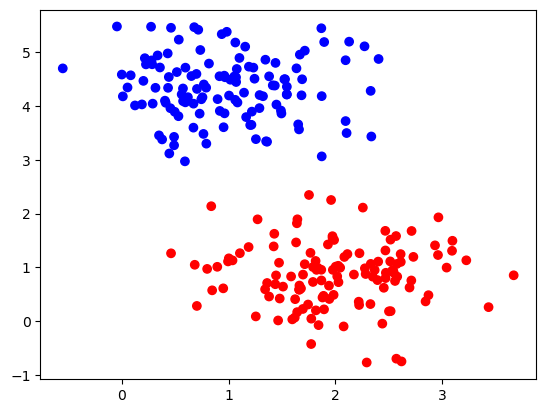

In [13]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr')

We split the data into training and testing sets.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

Then, we create and train an instance of our support vector machine class.

In [15]:
svm = SVM()
svm.fit(X_train, y_train)

     pcost       dcost       gap    pres   dres
 0: -1.8226e+01 -3.4458e+01  6e+02  2e+01  2e+00
 1: -2.5252e+01 -1.8773e+01  2e+02  9e+00  7e-01
 2: -5.3459e+01 -3.2711e+01  2e+02  7e+00  6e-01
 3: -7.8360e+01 -2.6482e+01  1e+02  4e+00  3e-01
 4: -5.6818e+00 -5.1750e+00  1e+01  2e-01  1e-02
 5: -3.6906e+00 -4.1082e+00  4e-01  2e-15  1e-14
 6: -4.0061e+00 -4.0104e+00  4e-03  1e-15  7e-15
 7: -4.0094e+00 -4.0094e+00  4e-05  6e-16  5e-15
 8: -4.0094e+00 -4.0094e+00  4e-07  1e-15  5e-15
Optimal solution found.


Next, we plot the decision boundary and support vectors.

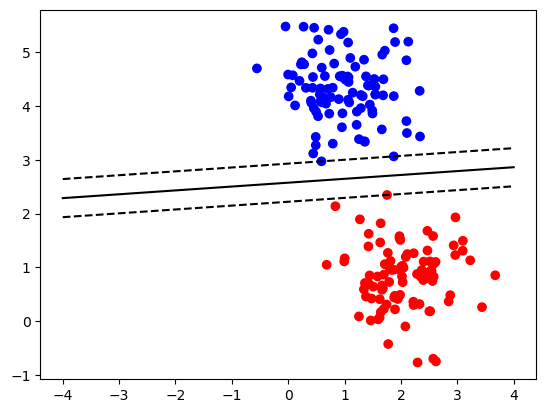

In [19]:
def f(x, w, b, c=0):
    return (-w[0] * x - b + c) / w[1]
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='bwr')

# w.x + b = 0
a0 = -4; a1 = f(a0, svm.w, svm.b)
b0 = 4; b1 = f(b0, svm.w, svm.b)
plt.plot([a0,b0], [a1,b1], 'k')

# w.x + b = 1
a0 = -4; a1 = f(a0, svm.w, svm.b, 1)
b0 = 4; b1 = f(b0, svm.w, svm.b, 1)
plt.plot([a0,b0], [a1,b1], 'k--')

# w.x + b = -1
a0 = -4; a1 = f(a0, svm.w, svm.b, -1)
b0 = 4; b1 = f(b0, svm.w, svm.b, -1)
plt.plot([a0,b0], [a1,b1], 'k--')

We use our model to predict the classes of the samples in the testing set. Given that we’re using our model to classify data, we use a confusion matrix to evaluate its accuracy.

In [20]:

y_pred = svm.predict(X_test)
confusion_matrix(y_test, y_pred)

array([[29,  0],
       [ 0, 34]])

<Axes: >

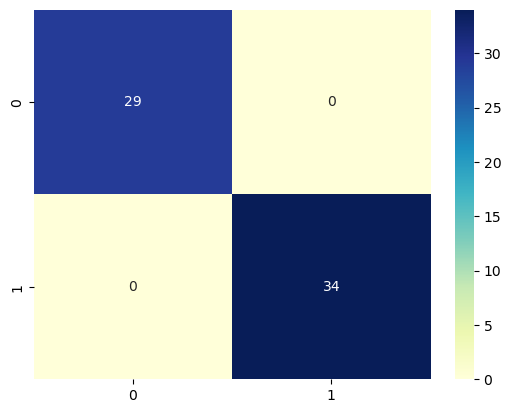

In [21]:
import seaborn as sns
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="YlGnBu")

## SVM using scikit learn LinearSVC library

Let’s attempt the same thing using the scikit-learn implementation of the support vector classifier.

In [22]:
svc = LinearSVC(verbose=1, tol=1e-5)
#svc = make_pipeline(StandardScaler(),
#              LinearSVC(random_state=0, tol=1e-5, verbose=1))
svc.fit(X_train, y_train)

[LibLinear]

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",1e-05
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rando

After training our model, we plot the decision boundary and support vectors.

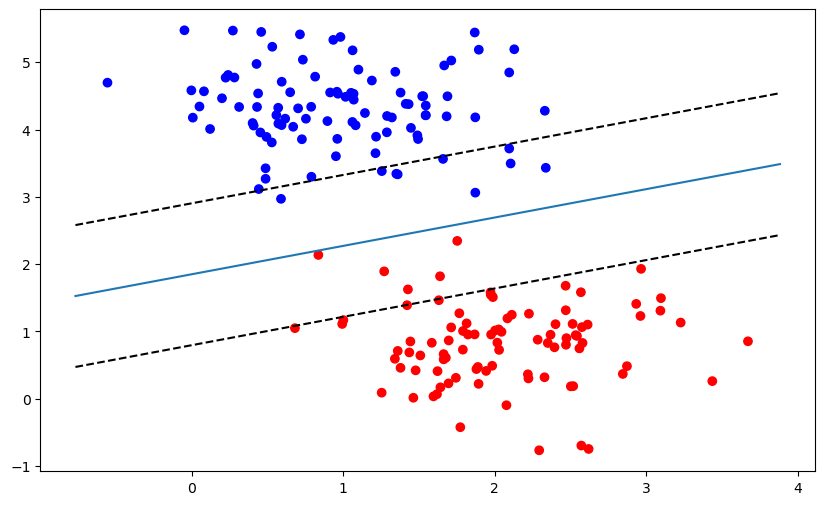

In [25]:
plt.figure(1, figsize=(10, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='bwr');
ax = plt.gca()

xlim = ax.get_xlim()
w = svc.coef_[0]
a = -w[0] / w[1]
xx = np.linspace(xlim[0], xlim[1])
yy = a * xx - svc.intercept_[0] / w[1]
plt.plot(xx, yy)
yy = a * xx - (svc.intercept_[0] - 1) / w[1]
plt.plot(xx, yy, 'k--')
yy = a * xx - (svc.intercept_[0] + 1) / w[1]
plt.plot(xx, yy, 'k--')


Again, we predict which sample belongs to what class based off which side of the line they fall.

In [26]:
y_pred = svc.predict(X_test)
confusion_matrix(y_test, y_pred)

array([[29,  0],
       [ 0, 34]])

<Axes: >

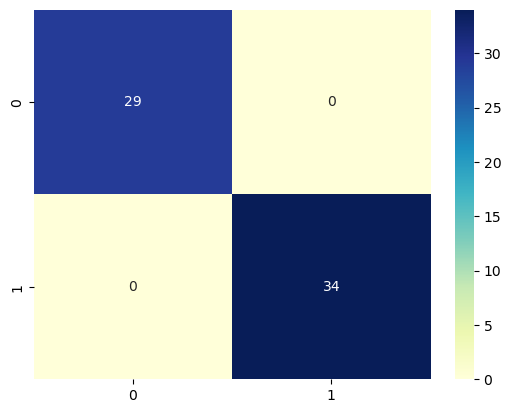

In [27]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="YlGnBu")

### SVM using SciKit Learn svm module

In [28]:
from sklearn import svm
clf = svm.SVC(kernel='linear', C=0.05)
clf.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.05
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


#### Let plot the results

C:\Users\chw\AppData\Local\Temp\ipykernel_82104\1268806761.py:38: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  plt.figure(fignum, figsize=(10, 6))


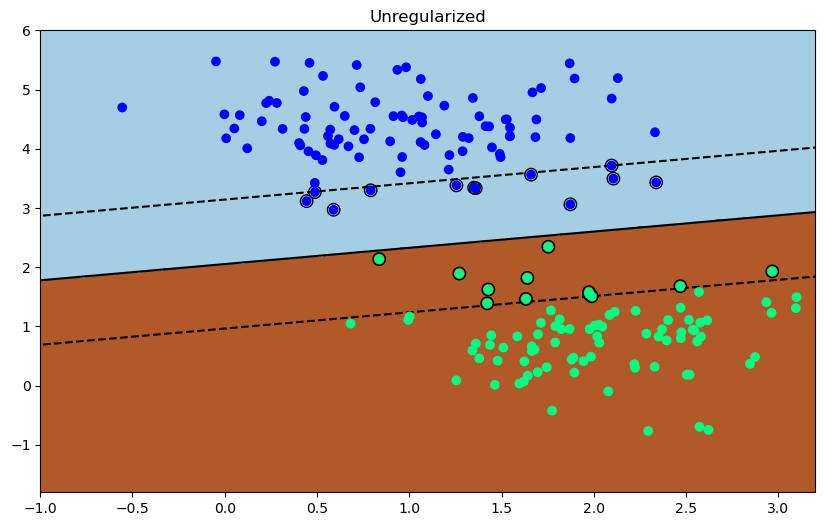

In [29]:
# get the separating hyperplane
w = clf.coef_[0]
a = -w[0] / w[1]
xx = np.linspace(-5, 5)
yy = a * xx - (clf.intercept_[0]) / w[1]
fignum = 1
# plot the parallels to the separating hyperplane that pass through the
# support vectors (margin away from hyperplane in direction
# perpendicular to hyperplane). This is sqrt(1+a^2) away vertically in
# 2-d.
margin = 1 / np.sqrt(np.sum(clf.coef_ ** 2))
yy_down = yy - np.sqrt(1 + a ** 2) * margin
yy_up = yy + np.sqrt(1 + a ** 2) * margin

# plot the line, the points, and the nearest vectors to the plane
plt.figure(fignum, figsize=(10, 6))
plt.clf()
plt.plot(xx, yy, 'k-')
plt.plot(xx, yy_down, 'k--')
plt.plot(xx, yy_up, 'k--')

plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=80,
            facecolors='none', zorder=10, edgecolors='k')
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, zorder=10, cmap="winter")

plt.axis('tight')
plt.title('Unregularized') 
x_min = -1.0
x_max = 3.2
y_min = -1.8
y_max = 6

XX, YY = np.mgrid[x_min:x_max:200j, y_min:y_max:200j]
Z = clf.predict(np.c_[XX.ravel(), YY.ravel()])

# Put the result into a color plot
Z = Z.reshape(XX.shape)
plt.figure(fignum, figsize=(10, 6))
plt.pcolormesh(XX, YY, Z, cmap=plt.cm.Paired)

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

#plt.xticks(())
#plt.yticks(())


plt.show()

In [30]:
y_pred = svc.predict(X_test)
confusion_matrix(y_test, y_pred)

array([[29,  0],
       [ 0, 34]])

<Axes: >

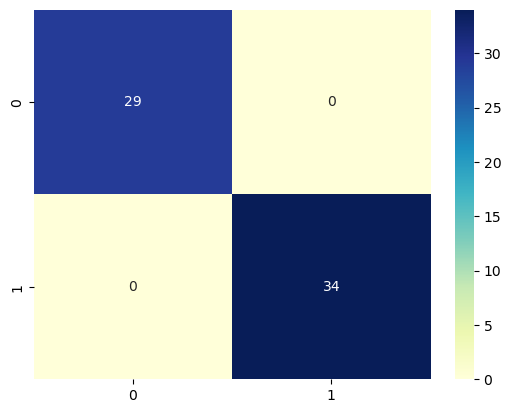

In [31]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="YlGnBu")

# Conclusion
We saw how we could go about using the Lagrangian to determine the line that best separates our data. In the real world, most problems are not linear separable. Thus, we make use of something called the kernel trick to separate the data using something other than a straight line. Stay tuned for an upcoming article where we cover this topic.

More detail discussion on Support Vector Machine for classification and regression using SciKit Learn can be found:<br>
https://scikit-learn.org/stable/modules/svm.html


reference: https://towardsdatascience.com/support-vector-machine-python-example-d67d9b63f1c8


===================================================================
Support Vector Regression (SVR) using linear and non-linear kernels
===================================================================

### Toy example of 1D regression using linear, polynomial and RBF kernels.


In [32]:
import numpy as np
from sklearn.svm import SVR
import matplotlib.pyplot as plt

# #############################################################################
# Generate sample data
X = np.sort(5 * np.random.rand(40, 1), axis=0)
y = np.sin(X).ravel()

# #############################################################################
# Add noise to targets
y[::5] += 3 * (0.5 - np.random.rand(8))

# Fit regression models RBF, Linear, and polynomial

In [33]:
svr_rbf = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=.1)
svr_lin = SVR(kernel='linear', C=100, gamma='auto')
svr_poly = SVR(kernel='poly', C=100, gamma='auto', degree=3, epsilon=.1,
               coef0=1)

# #############################################################################

## Look at the results
========================

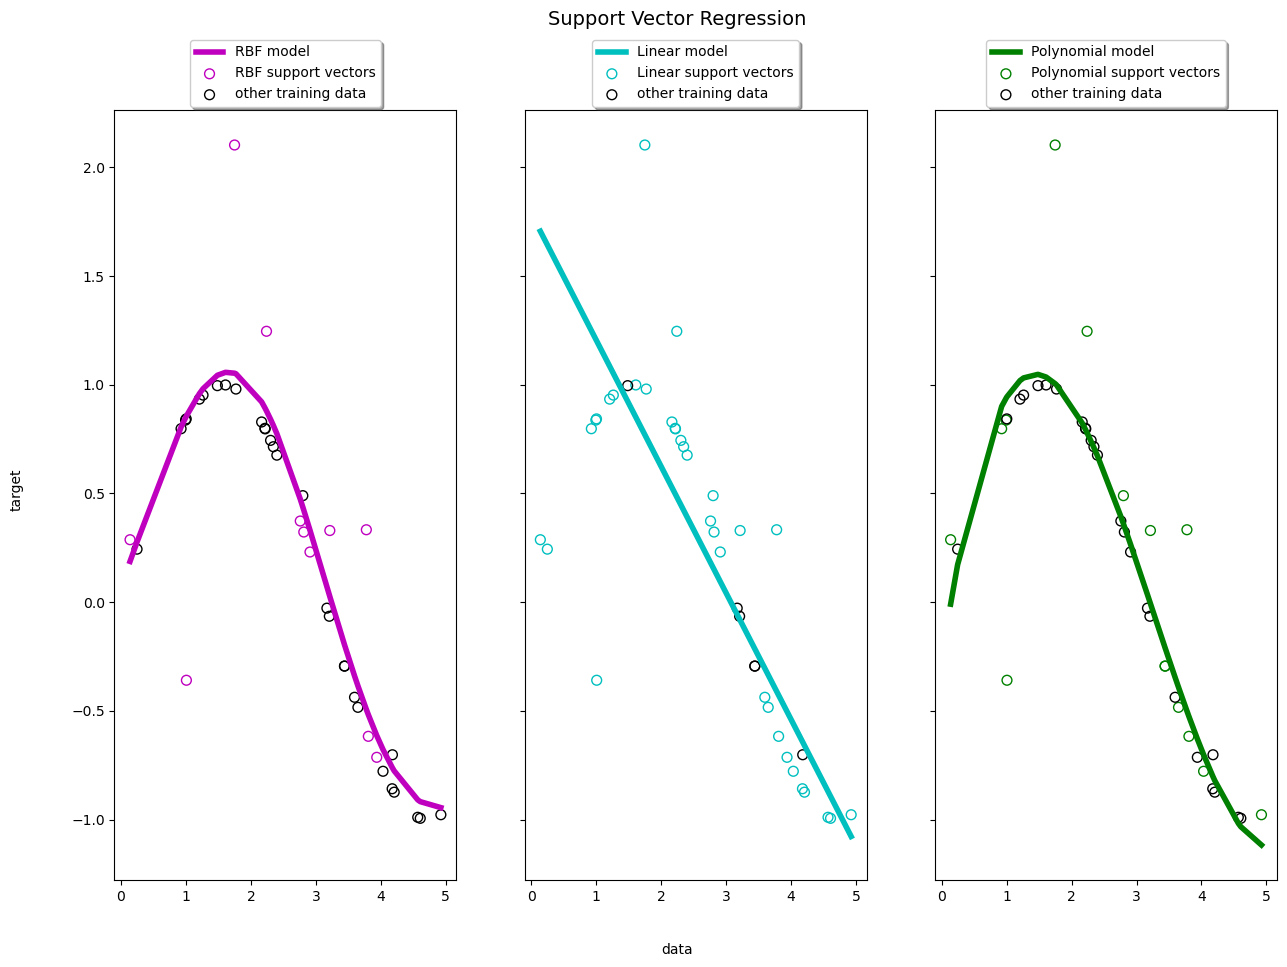

In [34]:
lw = 4 #Adjust the line weight in the plot

svrs = [svr_rbf, svr_lin, svr_poly]
kernel_label = ['RBF', 'Linear', 'Polynomial']
model_color = ['m', 'c', 'g']

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 10), sharey=True)
for ix, svr in enumerate(svrs):
    axes[ix].plot(X, svr.fit(X, y).predict(X), color=model_color[ix], lw=lw,
                  label='{} model'.format(kernel_label[ix]))
    axes[ix].scatter(X[svr.support_], y[svr.support_], facecolor="none",
                     edgecolor=model_color[ix], s=50,
                     label='{} support vectors'.format(kernel_label[ix]))
    axes[ix].scatter(X[np.setdiff1d(np.arange(len(X)), svr.support_)],
                     y[np.setdiff1d(np.arange(len(X)), svr.support_)],
                     facecolor="none", edgecolor="k", s=50,
                     label='other training data')
    axes[ix].legend(loc='upper center', bbox_to_anchor=(0.5, 1.1),
                    ncol=1, fancybox=True, shadow=True)

fig.text(0.5, 0.04, 'data', ha='center', va='center')
fig.text(0.06, 0.5, 'target', ha='center', va='center', rotation='vertical')
fig.suptitle("Support Vector Regression", fontsize=14)
plt.show()

# Non-linear SVM
Perform binary classification using non-linear SVC with RBF kernel. The target to predict is a XOR of the inputs.

The color map illustrates the decision function learned by the SVC.

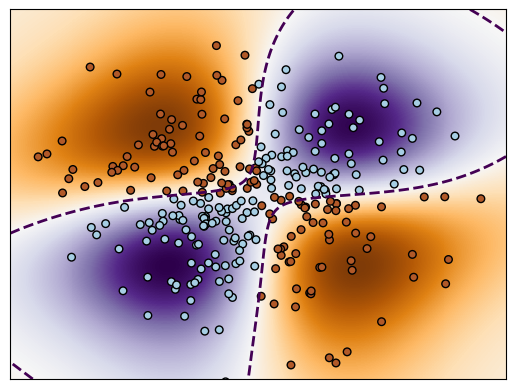

In [35]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn import svm

xx, yy = np.meshgrid(np.linspace(-3, 3, 500), np.linspace(-3, 3, 500))
np.random.seed(0)
X = np.random.randn(300, 2)
Y = np.logical_xor(X[:, 0] > 0, X[:, 1] > 0)

# fit the model
clf = svm.NuSVC(gamma="auto")
clf.fit(X, Y)

# plot the decision function for each datapoint on the grid
Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.imshow(
    Z,
    interpolation="nearest",
    extent=(xx.min(), xx.max(), yy.min(), yy.max()),
    aspect="auto",
    origin="lower",
    cmap=plt.cm.PuOr_r,
)
contours = plt.contour(xx, yy, Z, levels=[0], linewidths=2, linestyles="dashed")
plt.scatter(X[:, 0], X[:, 1], s=30, c=Y, cmap=plt.cm.Paired, edgecolors="k")
plt.xticks(())
plt.yticks(())
plt.axis([-3, 3, -3, 3])
plt.show()